# Practical Exercise 2 - Task 1
# Vanilla GAN on MNIST

This notebook implements a Vanilla GAN for MNIST using a modern PyTorch setup.

## Goals
- Build a Generator and a Discriminator
- Train them adversarially on MNIST
- Visualize generated digit samples

In [1]:
import os
import sys
import platform
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib_inline.backend_inline as _backend_inline

import torch
import torch.nn as nn
import torch.optim as optim
import wandb

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
# Render inline plots as SVG for crisp notebook figures
_backend_inline.set_matplotlib_formats("svg")

In [3]:
def device_check() -> torch.device:
    """Detect the best available device and print a summary."""
    print(f"PyTorch: {torch.__version__} | "
          f"Python: {sys.version.split()[0]} | "
          f"OS: {platform.system()} {platform.release()}")

    cuda_available = torch.cuda.is_available()
    print(f"CUDA available: {cuda_available}")

    if cuda_available:
        device = torch.device("cuda")
        gpu_count = torch.cuda.device_count()
        gpu_name = torch.cuda.get_device_name(0)
        total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPUs: {gpu_count} x {gpu_name} ({total_mem:.1f} GB)")
        print(f"CUDA: {torch.version.cuda} | "
              f"cuDNN: {torch.backends.cudnn.version()}")
        print(f"Using cuda / {gpu_name}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using mps (Apple Silicon)")
    else:
        device = torch.device("cpu")
        print("Using cpu")

    return device


device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [4]:
# =====================
# Configuration
# =====================
seed = 1
batch_size = 64
z_dim = 100
x_dim = 28 * 28
h_dim = 128
lr = 1e-3

num_epochs = 10
sample_every = 1

output_dir = Path("out_vanilla_gan")
output_dir.mkdir(parents=True, exist_ok=True)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [5]:
# =====================
# Weights & Biases setup
# =====================
use_wandb = True

wandb_project = "lab2-vanilla-gan"
wandb_run_name = "vanilla-gan-mnist"

wandb_config = {
    "seed": seed,
    "batch_size": batch_size,
    "z_dim": z_dim,
    "x_dim": x_dim,
    "h_dim": h_dim,
    "lr": lr,
    "num_epochs": num_epochs,
    "model": "Vanilla GAN",
    "dataset": "MNIST",
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
}

if use_wandb:
    wandb.init(
        project=wandb_project,
        name=wandb_run_name,
        config=wandb_config,
    )

def make_wandb_image(samples: torch.Tensor, title: str = "Generated Samples"):
    """Create a wandb.Image from generated samples."""
    samples = samples.detach().cpu().view(-1, 28, 28)[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect("equal")
        plt.imshow(sample.numpy(), cmap="gray")

    plt.suptitle(title)
    plt.tight_layout()

    image = wandb.Image(fig)
    plt.close(fig)
    return image

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Preparation

We use the MNIST training set.
Each image is converted to a tensor and flattened into a 784-dimensional vector.

In [6]:
# =====================
# Data
# =====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),
])

train_dataset = datasets.MNIST(
    root="./MNIST_data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=8,
    pin_memory=torch.cuda.is_available(),
)

print(f"Training samples: {len(train_dataset):,}")

Training samples: 60,000


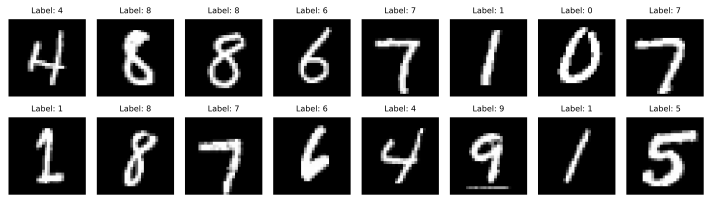

In [7]:
# Show a few real MNIST samples
real_batch, real_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(real_batch[i].view(28, 28), cmap="gray")
    ax.set_title(f"Label: {real_labels[i].item()}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model Definitions

The Generator maps random noise to fake images.
The Discriminator predicts whether an image is real or fake.

In [8]:
class Generator(nn.Module):
    """Simple MLP Generator for MNIST."""
    def __init__(self, z_dim: int, h_dim: int, x_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, h_dim),
            nn.ReLU(inplace=True),
            nn.Linear(h_dim, x_dim),
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class Discriminator(nn.Module):
    """Simple MLP Discriminator for MNIST."""
    def __init__(self, x_dim: int, h_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim, h_dim),
            nn.ReLU(inplace=True),
            nn.Linear(h_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [9]:
G = Generator(z_dim=z_dim, h_dim=h_dim, x_dim=x_dim).to(device)
D = Discriminator(x_dim=x_dim, h_dim=h_dim).to(device)

if torch.cuda.is_available():
    G = torch.compile(G)
    D = torch.compile(D)

print(G)
print(D)

OptimizedModule(
  (_orig_mod): Generator(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=128, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=128, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)
OptimizedModule(
  (_orig_mod): Discriminator(
    (net): Sequential(
      (0): Linear(in_features=784, out_features=128, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)


In [10]:
criterion = nn.BCEWithLogitsLoss()

G_optimizer = optim.Adam(G.parameters(), lr=lr)
D_optimizer = optim.Adam(D.parameters(), lr=lr)

scaler_G = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None
scaler_D = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

In [11]:
def sample_noise(batch_size: int, z_dim: int, device: torch.device) -> torch.Tensor:
    """Sample random latent vectors."""
    return torch.randn(batch_size, z_dim, device=device)


def plot_samples(samples: torch.Tensor, title: str = "Generated Samples") -> None:
    """Plot 16 generated MNIST samples."""
    samples = samples.detach().cpu().view(-1, 28, 28)[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect("equal")
        plt.imshow(sample.numpy(), cmap="gray")

    plt.suptitle(title)
    plt.show()


def save_sample_grid(samples: torch.Tensor, file_path: Path) -> None:
    """Save 16 generated samples to disk."""
    samples = samples.detach().cpu().view(-1, 28, 28)[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect("equal")
        plt.imshow(sample.numpy(), cmap="gray")

    plt.savefig(file_path, bbox_inches="tight")
    plt.close(fig)

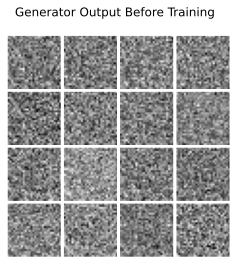

In [12]:
# Test Before Training
z = sample_noise(batch_size=16, z_dim=z_dim, device=device)
with torch.no_grad():
    fake_images = G(z)

plot_samples(fake_images, title="Generator Output Before Training")

## Training Loop

Training alternates between:
1. Updating the Discriminator
2. Updating the Generator

In [13]:
# =====================
# Training Helpers
# =====================

def train_discriminator(
    D: nn.Module,
    G: nn.Module,
    real_images: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler=None,
) -> float:
    """One discriminator update step."""
    device = real_images.device
    batch_size = real_images.size(0)
    cuda_enabled = (device.type == "cuda")

    real_labels = torch.ones(batch_size, 1, device=device)
    fake_labels = torch.zeros(batch_size, 1, device=device)

    z = sample_noise(batch_size, z_dim, device)
    fake_images = G(z).detach()

    optimizer.zero_grad()

    with torch.autocast(device_type=device.type, enabled=cuda_enabled):
        d_real = D(real_images)
        d_fake = D(fake_images)

        d_loss_real = criterion(d_real, real_labels)
        d_loss_fake = criterion(d_fake, fake_labels)
        d_loss = d_loss_real + d_loss_fake

    if scaler is not None:
        scaler.scale(d_loss).backward()
        scaler.step(optimizer)
        scaler.update()
    else:
        d_loss.backward()
        optimizer.step()

    return float(d_loss.item())


def train_generator(
    D: nn.Module,
    G: nn.Module,
    batch_size: int,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler=None,
) -> float:
    """One generator update step."""
    device = next(G.parameters()).device
    cuda_enabled = (device.type == "cuda")

    real_labels = torch.ones(batch_size, 1, device=device)
    z = sample_noise(batch_size, z_dim, device)

    optimizer.zero_grad()

    with torch.autocast(device_type=device.type, enabled=cuda_enabled):
        fake_images = G(z)
        d_fake = D(fake_images)

        # Non-saturating generator loss
        g_loss = criterion(d_fake, real_labels)

    if scaler is not None:
        scaler.scale(g_loss).backward()
        scaler.step(optimizer)
        scaler.update()
    else:
        g_loss.backward()
        optimizer.step()

    return float(g_loss.item())

Epoch | D Loss       | G Loss      
 1/10 | 0.1449       | 4.9295      


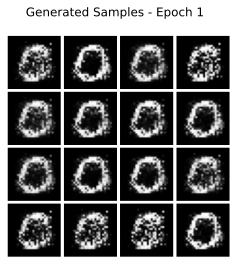

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 2/10 | 0.1128       | 4.3016      


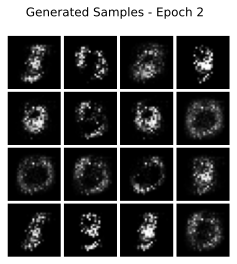

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 3/10 | 0.1695       | 4.0587      


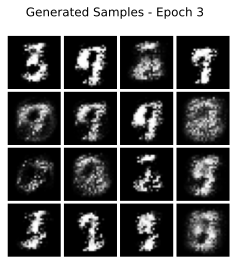

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 4/10 | 0.3604       | 3.9225      


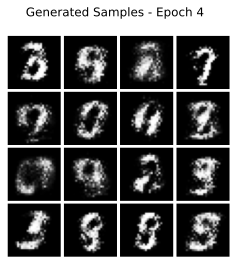

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 5/10 | 0.4539       | 3.7137      


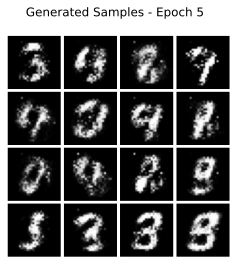

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 6/10 | 0.5574       | 3.5719      


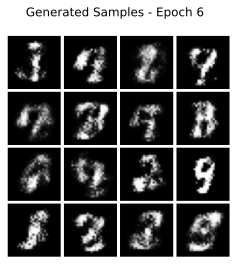

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 7/10 | 0.6837       | 2.8509      


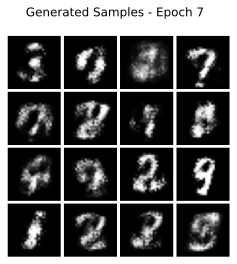

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 8/10 | 0.8711       | 2.5164      


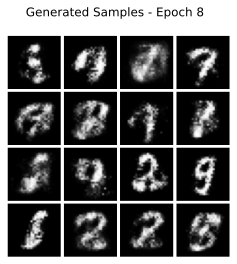

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


 9/10 | 0.8912       | 2.3793      


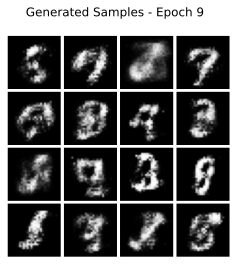

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


10/10 | 0.9063       | 2.2567      


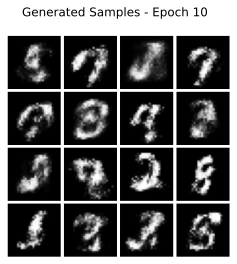

/tmp/ipykernel_691704/1636261795.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [14]:
# =====================
# Training Loop
# =====================

history: Dict[str, List[float]] = {
    "D Loss": [],
    "G Loss": [],
}

fixed_z = sample_noise(16, z_dim, device)

w = len(str(num_epochs))
epoch_col_w = max(2 * w + 1, 5)
col_w = 12

header = (
    f"{'Epoch':<{epoch_col_w}} | "
    f"{'D Loss':<{col_w}} | "
    f"{'G Loss':<{col_w}}"
)
print(header)

for epoch in range(1, num_epochs + 1):
    d_loss_running = 0.0
    g_loss_running = 0.0
    n_batches = 0

    G.train()
    D.train()

    for real_images, _ in train_loader:
        real_images = real_images.to(device, non_blocking=torch.cuda.is_available())

        d_loss = train_discriminator(
            D=D,
            G=G,
            real_images=real_images,
            optimizer=D_optimizer,
            criterion=criterion,
            scaler=scaler_D,
        )

        g_loss = train_generator(
            D=D,
            G=G,
            batch_size=real_images.size(0),
            optimizer=G_optimizer,
            criterion=criterion,
            scaler=scaler_G,
        )

        d_loss_running += d_loss
        g_loss_running += g_loss
        n_batches += 1

    avg_d_loss = d_loss_running / n_batches
    avg_g_loss = g_loss_running / n_batches

    history["D Loss"].append(avg_d_loss)
    history["G Loss"].append(avg_g_loss)

    epoch_str = f"{epoch:>{w}}/{num_epochs:>{w}}"
    print(
        f"{epoch_str:<{epoch_col_w}} | "
        f"{avg_d_loss:<{col_w}.4f} | "
        f"{avg_g_loss:<{col_w}.4f}"
    )

    G.eval()
    with torch.no_grad():
        samples = G(fixed_z)

    if epoch % sample_every == 0:
        plot_samples(samples, title=f"Generated Samples - Epoch {epoch}")
        save_sample_grid(samples, output_dir / f"epoch_{epoch:03d}.png")

    if use_wandb:
        log_dict = {
            "epoch": epoch,
            "D_loss": avg_d_loss,
            "G_loss": avg_g_loss,
        }

        if epoch % sample_every == 0:
            log_dict["generated_samples"] = make_wandb_image(
                samples,
                title=f"Generated Samples - Epoch {epoch}"
            )

        wandb.log(log_dict)

In [15]:
if use_wandb:
    wandb.finish()

D_loss,▁▁▂▃▄▅▆███
G_loss,█▆▆▅▅▄▃▂▁▁
epoch,▁▂▃▃▄▅▆▆▇█
D_loss,0.90632
G_loss,2.25675
epoch,10


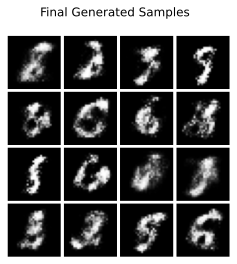

In [19]:
G.eval()
z = sample_noise(16, z_dim, device)

with torch.no_grad():
    final_samples = G(z)

plot_samples(final_samples, title="Final Generated Samples")

In [20]:
torch.save(getattr(G, "_orig_mod", G).state_dict(), "generator_vanilla_gan.pt")
torch.save(getattr(D, "_orig_mod", D).state_dict(), "discriminator_vanilla_gan.pt")

print("Model weights saved successfully.")

Model weights saved successfully.
